In [3]:
# Célula 1: Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Carregar dados (versão sem escala para análise)
df = pd.read_csv('../data/features/df_features_arvore.csv')
target_col = 'inadipl_90dias_ult2anos'

X = df.drop(columns=[target_col])
y = df[target_col]

print("=" * 80)
print("🎯 SELEÇÃO DE FEATURES")
print("=" * 80)
print(f"\n📊 Dataset:")
print(f"   Features: {X.shape[1]}")
print(f"   Samples: {X.shape[0]}")

🎯 SELEÇÃO DE FEATURES

📊 Dataset:
   Features: 45
   Samples: 149234


# Remover Features Correlacionadas

In [18]:
# calcular matriz de correlação
# selecionar triangulo superior
# Selecionar apenas colunas numéricas
X_num = X.select_dtypes(include=[np.number])
# Célula 2: Remover Features Correlacionadas
print("=" * 80)
print("🔗 REMOVENDO FEATURES ALTAMENTE CORRELACIONADAS")
print("=" * 80)

# Calcular matriz de correlação
corr_matrix = X_num.corr().abs()

# Selecionar triângulo superior
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Encontrar features com correlação > 0.95
threshold = 0.95
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

print(f"\n📊 Features com correlação > {threshold}:")
if len(to_drop) > 0:
    for feat in to_drop:
        # Encontrar com qual feature está correlacionada
        correlated_with = upper_tri[feat][upper_tri[feat] > threshold].index.tolist()
        if correlated_with:
            print(f"   ❌ {feat:40s} (corr. com {correlated_with[0]})")
    
    # Remover
    X_reduced = X_num.drop(columns=to_drop)
    print(f"\n✅ {len(to_drop)} features removidas")
    print(f"   Shape: {X.shape} → {X_reduced.shape}")
else:
    print("   ✅ Nenhuma feature altamente correlacionada")
    X_reduced = X.copy()

🔗 REMOVENDO FEATURES ALTAMENTE CORRELACIONADAS

📊 Features com correlação > 0.95:
   ❌ atrasos_30dias                           (corr. com indice_severidade_atrasos)
   ❌ atrasos_90dias                           (corr. com indice_severidade_atrasos)
   ❌ dependentes                              (corr. com indice_severidade_atrasos)
   ❌ comprometimento_renda_missing            (corr. com renda_mensal_missing)
   ❌ idade_centralizada                       (corr. com idade)
   ❌ idade_raiz                               (corr. com idade)
   ❌ score_ponderado_atrasos                  (corr. com indice_severidade_atrasos)
   ❌ indice_pressao_financeira                (corr. com divida_ratio)

✅ 8 features removidas
   Shape: (149234, 45) → (149234, 34)



🌳 FEATURE IMPORTANCE (RANDOM FOREST)

🔄 Treinando Random Forest...
✅ Modelo treinado!

🎯 Top 20 Features mais importantes:
                       feature  importance
     indice_severidade_atrasos    0.294333
     pressao_dependentes_renda    0.103024
            utilizacao_credito    0.097048
   utilizacao_credito_quadrado    0.085272
              renda_per_capita    0.060181
        utilizacao_media_linha    0.046620
          alta_utilizacao_flag    0.032145
        utilizacao_credito_bin    0.028864
         interacao_idade_renda    0.024912
        baixa_renda_por_pessoa    0.023965
       interacao_divida_linhas    0.022406
                  divida_ratio    0.021920
comprometimento_renda_ajustado    0.020463
                         idade    0.020310
                  renda_mensal    0.017555
              renda_disponivel    0.017138
        linhas_credito_abertas    0.016884
              log_renda_mensal    0.016556
                idade_quadrado    0.014593
     emprestimos

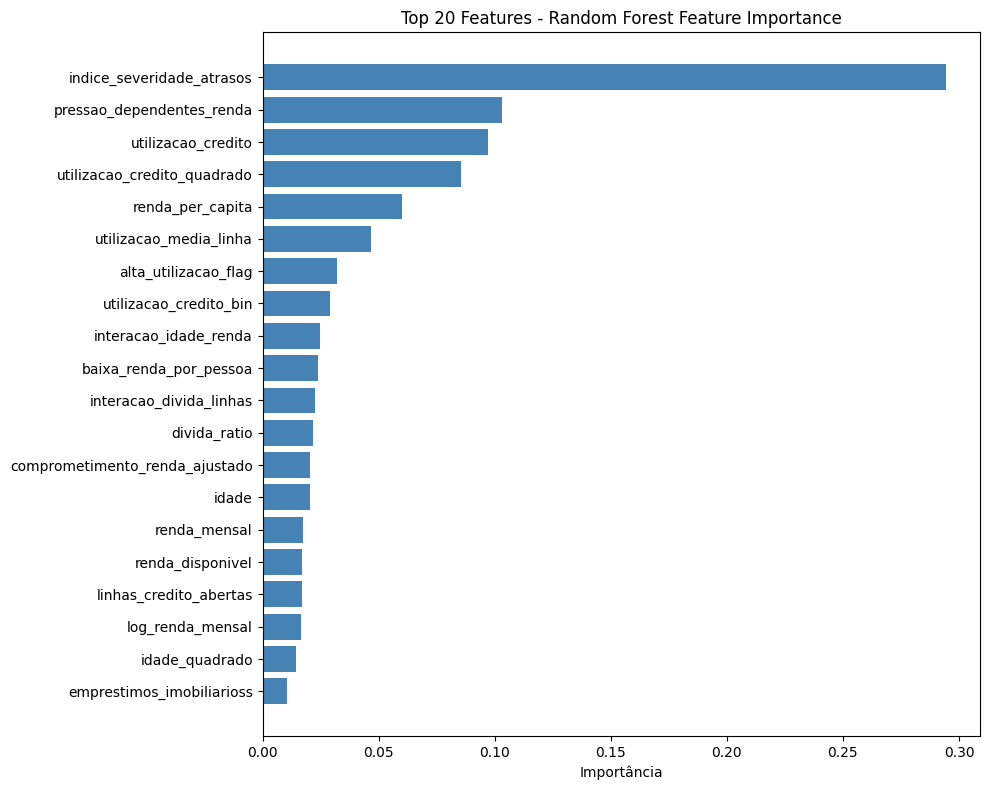


✅ Features com importância > 0.01:
   Total: 20 features


In [21]:
# Célula 3: Feature Importance com Random Forest
print("\n" + "=" * 80)
print("🌳 FEATURE IMPORTANCE (RANDOM FOREST)")
print("=" * 80)

print("\n🔄 Treinando Random Forest...")
# Treinar modelo rápido
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_reduced, y)
print("✅ Modelo treinado!")

# Obter importâncias
feature_importance = pd.DataFrame({
    'feature': X_reduced.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n🎯 Top 20 Features mais importantes:")
print(feature_importance.head(20).to_string(index=False))

# Visualizar
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
plt.xlabel('Importância')
plt.title('Top 20 Features - Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Selecionar features importantes (importância > threshold)
importance_threshold = 0.01  # 1%
important_features = feature_importance[
    feature_importance['importance'] > importance_threshold
]['feature'].tolist()

print(f"\n✅ Features com importância > {importance_threshold}:")
print(f"   Total: {len(important_features)} features")

## Informacao Mutua

Top 20 Features (Informacao Mutua
                     feature  mi_score
   indice_severidade_atrasos  0.047080
      utilizacao_credito_bin  0.038019
 utilizacao_credito_quadrado  0.037326
          utilizacao_credito  0.036873
      utilizacao_media_linha  0.028370
          flag_possui_imovel  0.027939
comprometimento_outlier_flag  0.027276
            renda_per_capita  0.025609
   pressao_dependentes_renda  0.023422
        alta_utilizacao_flag  0.023145
        flag_cliente_estavel  0.021509
      baixa_renda_por_pessoa  0.016127
     estabilidade_financeira  0.014101
                       idade  0.008919
             flag_alto_risco  0.008150
            faixa_etaria_num  0.007857
              idade_quadrado  0.007229
   emprestimos_imobiliarioss  0.007015
       interacao_idade_renda  0.006268
      linhas_credito_abertas  0.005534


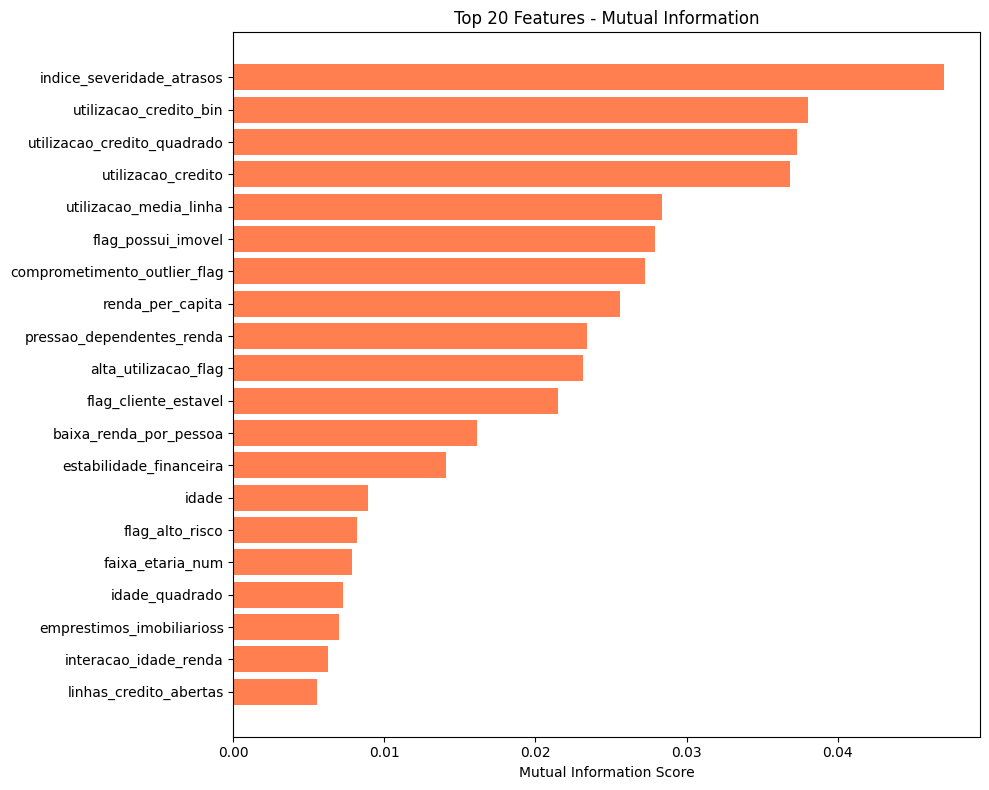

In [27]:
# Substituir NaN por 0 (ou outro valor neutro)
X_filled = X_reduced.fillna(0)
mi_scores = mutual_info_classif(X_filled, y , random_state=42)

mi_df= pd.DataFrame({'feature':X_filled.columns,'mi_score': mi_scores}).sort_values(
    'mi_score', ascending=False)
print("Top 20 Features (Informacao Mutua")
print(mi_df.head(20).to_string(index=False))

# Visualizar
plt.figure(figsize=(10, 8))
top_mi = mi_df.head(20)
plt.barh(top_mi['feature'], top_mi['mi_score'], color='coral')
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Features - Mutual Information')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Eliminação recursiva de feature (RFE)

In [34]:
# Usar modelo de regressão Logistica porque é mais simples,rápida e une seleção de variaveis com interpretabilidade.
n_features_to_select = min(40,len(important_features))
estimator = LogisticRegression(max_iter=100,random_state=42)
rfe = RFE(estimator=estimator, n_features_to_select=n_features_to_select, step=5)

# Aplicar apenas nas features importantes (para acelerar)
X_important = X_reduced[important_features]
rfe.fit(X_important,y)

#features selecionadas
rfe_features = X_important.columns[rfe.support_].tolist()
print(f"   Features selecionadas: {len(rfe_features)}")

# Ranking
rfe_ranking = pd.DataFrame({
    'feature': X_important.columns,
    'ranking': rfe.ranking_,
    'selected': rfe.support_
}).sort_values('ranking')

print(" Top 20 Features (RFE Ranking):")
print(rfe_ranking.head(20).to_string(index=False))

   Features selecionadas: 20
 Top 20 Features (RFE Ranking):
                       feature  ranking  selected
     indice_severidade_atrasos        1      True
     pressao_dependentes_renda        1      True
            utilizacao_credito        1      True
   utilizacao_credito_quadrado        1      True
              renda_per_capita        1      True
        utilizacao_media_linha        1      True
          alta_utilizacao_flag        1      True
        utilizacao_credito_bin        1      True
         interacao_idade_renda        1      True
        baixa_renda_por_pessoa        1      True
       interacao_divida_linhas        1      True
                  divida_ratio        1      True
comprometimento_renda_ajustado        1      True
                         idade        1      True
                  renda_mensal        1      True
              renda_disponivel        1      True
        linhas_credito_abertas        1      True
              log_renda_mensal        1

## Combinar Métodos de Seleção

In [35]:
# Célula 6: Combinar Métodos de Seleção
print("\n" + "=" * 80)
print("🎯 COMBINANDO MÉTODOS DE SELEÇÃO")
print("=" * 80)

# Features que aparecem nos top 30 de pelo menos 2 métodos
rf_top = feature_importance.head(30)['feature'].tolist()
mi_top = mi_df.head(30)['feature'].tolist()
rfe_top = rfe_features

# Contar aparições
feature_votes = {}
for feat in X_reduced.columns:
    votes = 0
    if feat in rf_top:
        votes += 1
    if feat in mi_top:
        votes += 1
    if feat in rfe_top:
        votes += 1
    
    if votes > 0:
        feature_votes[feat] = votes

# Ordenar por votos
feature_votes_df = pd.DataFrame(
    list(feature_votes.items()),
    columns=['feature', 'votes']
).sort_values('votes', ascending=False)

print(f"\n📊 Consenso entre Métodos:")
print(f"\n   Features com 3 votos (todos métodos): {len(feature_votes_df[feature_votes_df['votes']==3])}")
print(f"   Features com 2 votos: {len(feature_votes_df[feature_votes_df['votes']==2])}")
print(f"   Features com 1 voto: {len(feature_votes_df[feature_votes_df['votes']==1])}")

# Selecionar features com pelo menos 2 votos
final_features = feature_votes_df[feature_votes_df['votes'] >= 2]['feature'].tolist()

print(f"\n✅ Features Selecionadas (2+ votos): {len(final_features)}")
print(f"\n🎯 Top 30 Features Finais:")
for i, feat in enumerate(final_features[:30], 1):
    votes = feature_votes[feat]
    print(f"   {i:2d}. {feat:50s} ({votes} votos)")


🎯 COMBINANDO MÉTODOS DE SELEÇÃO

📊 Consenso entre Métodos:

   Features com 3 votos (todos métodos): 20
   Features com 2 votos: 8
   Features com 1 voto: 4

✅ Features Selecionadas (2+ votos): 28

🎯 Top 30 Features Finais:
    1. utilizacao_credito                                 (3 votos)
    2. indice_severidade_atrasos                          (3 votos)
    3. alta_utilizacao_flag                               (3 votos)
    4. renda_per_capita                                   (3 votos)
    5. baixa_renda_por_pessoa                             (3 votos)
    6. idade                                              (3 votos)
    7. utilizacao_media_linha                             (3 votos)
    8. renda_disponivel                                   (3 votos)
    9. comprometimento_renda_ajustado                     (3 votos)
   10. renda_mensal                                       (3 votos)
   11. linhas_credito_abertas                             (3 votos)
   12. divida_ratio        

## Dataset Final

In [40]:
# Criar datasets finais (para cada versão de scaling)
scaling_versions = ['no_scale', 'standardized', 'normalized']

for version in scaling_versions:
    # Carregar versão
    df_version = pd.read_csv(f'../data/features/df_features_arvore.csv')
    
    # Selecionar apenas features finais + target
    df_final = df_version[final_features + [target_col]]
    
    # Salvar
    output_path = f'../data/processed_data/data_{version}_selected.csv'
    df_final.to_csv(output_path, index=False)
    
    print(f"✅ {output_path}")
    print(f"   Shape: {df_version.shape} → {df_final.shape}")
    print(f"   Redução: {df_version.shape[1] - df_final.shape[1]} features")

✅ ../data/processed_data/data_no_scale_selected.csv
   Shape: (149234, 46) → (149234, 29)
   Redução: 17 features
✅ ../data/processed_data/data_standardized_selected.csv
   Shape: (149234, 46) → (149234, 29)
   Redução: 17 features
✅ ../data/processed_data/data_normalized_selected.csv
   Shape: (149234, 46) → (149234, 29)
   Redução: 17 features


In [41]:
# Salvar lista de features selecionadas
with open('../reports/selected_features.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("FEATURES SELECIONADAS PARA MODELAGEM\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Total: {len(final_features)} features\n")
    f.write(f"Métodos usados: Random Forest, Mutual Information, RFE\n")
    f.write(f"Critério: Features com 2+ votos\n\n")
    f.write("=" * 80 + "\n")
    f.write("LISTA DE FEATURES\n")
    f.write("=" * 80 + "\n\n")
    
    for i, feat in enumerate(final_features, 1):
        votes = feature_votes[feat]
        f.write(f"{i:3d}. {feat:50s} ({votes} votos)\n")

print("✅ Lista salva em: reports/selected_features.txt")

# Salvar também análise detalhada
feature_votes_df.to_csv('../reports/feature_selection_analysis.csv', index=False)
print("✅ Análise detalhada salva em: reports/feature_selection_analysis.csv")

✅ Lista salva em: reports/selected_features.txt
✅ Análise detalhada salva em: reports/feature_selection_analysis.csv



📊 VISUALIZAÇÃO FINAL


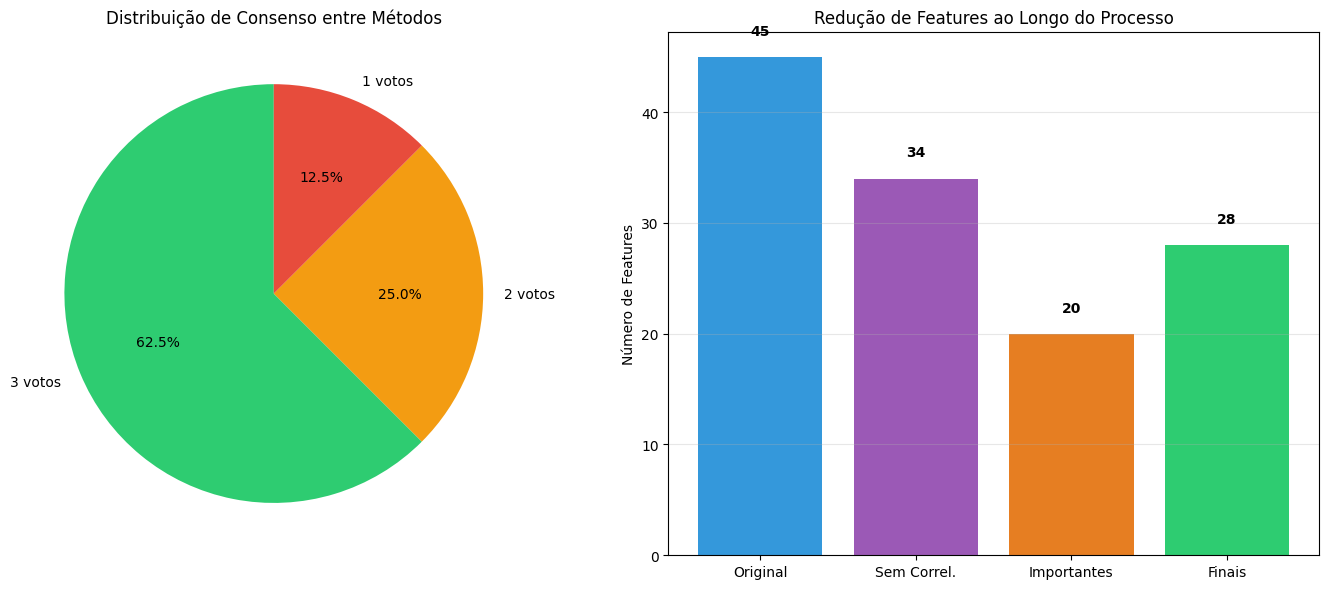


✅ Processo de seleção completo!
   Redução total: 45 → 28 features
   Percentual mantido: 62.2%


In [42]:
# Célula 9: Visualização Final
print("\n" + "=" * 80)
print("📊 VISUALIZAÇÃO FINAL")
print("=" * 80)

# Gráfico de pizza: distribuição de votos
vote_counts = feature_votes_df['votes'].value_counts().sort_index(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pizza
axes[0].pie(vote_counts.values, labels=[f'{v} votos' for v in vote_counts.index],
           autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Distribuição de Consenso entre Métodos')

# Barras: redução de features ao longo do processo
stages = ['Original', 'Sem Correl.', 'Importantes', 'Finais']
n_features_stages = [
    X.shape[1],
    X_reduced.shape[1],
    len(important_features),
    len(final_features)
]

axes[1].bar(stages, n_features_stages, color=['#3498db', '#9b59b6', '#e67e22', '#2ecc71'])
axes[1].set_ylabel('Número de Features')
axes[1].set_title('Redução de Features ao Longo do Processo')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(n_features_stages):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ Processo de seleção completo!")
print(f"   Redução total: {X.shape[1]} → {len(final_features)} features")
print(f"   Percentual mantido: {len(final_features)/X.shape[1]*100:.1f}%")